## Regression - Online Retail Sales Prediction

This project focuses on predicting daily sales volume using transaction data from the Online Retail dataset. The transaction-level data is cleaned and aggregated based on Date and Country to create meaningful daily-level features such as total items sold, total orders, and product variation count.

Multiple regression algorithms are trained and compared using R², RMSE, and MAE. Hyperparameter tuning is then performed on selected models using GridSearchCV, followed by evaluation and visualization of the final model's predictions and residuals.

Objective: Build and evaluate regression models that can predict daily_sales_volume while following a proper machine-learning pipeline with data cleaning, feature engineering, preprocessing, model comparison, and validation.

### Import Required Libraries

The libraries below are used for data handling, numerical calculations, and visualisation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## Dataset Loading and Initial Audit

The raw Online Retail dataset is loaded using Pandas. An initial audit is performed to understand the dataset structure before preprocessing.

The audit includes:
- Dataset shape (number of rows and columns)
- Data types of each feature
- Missing-value counts
- Descriptive statistics for numerical features

This initial inspection helps identify the data quality issues that need to be addressed during preprocessing.

In [2]:
df = pd.read_csv(
    '../data/raw/data.csv',
    encoding='ISO-8859-1'
)
print("--- DATASET AUDIT ---")
print(f"Shape: {df.shape}")
print("\nData Types & Missing Values:")
df.info()
print("\nMissing Value Counts:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe().T)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count:,}")

--- DATASET AUDIT ---
Shape: (541909, 8)

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Value Counts:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Summary Statistics:
                count          mean          std       min       25%       50%  \
Quantity  

## Data Cleaning and Feature Creation

In this step, the cleaned transaction data is prepared for aggregation and regression analysis.

First, cancelled or invalid transactions are removed by keeping only rows with positive quantities and positive unit prices.

The `InvoiceDate` column is converted to datetime format. The following information is then extracted:
- `Date`
- `year`
- `month`
- `day_of_week`
- `hour`

The `TotalSales` feature is calculated for each transaction using:

**Total Sales = Quantity × Unit Price**

Finally, the transaction-level data will be aggregated by **Date** and **Country** to create the dataset used for regression analysis.

In [3]:
np.random.seed(42)

# 1. Filter out cancellations, returns, and invalid prices
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()


print("--- DATA CLEANING ---")
print(f"Original rows: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

--- DATA CLEANING ---
Original rows: 541,909
Rows after cleaning: 530,104
Rows removed: 11,805


It removes transactions where the quantity or price is zero or negative. These rows are not useful for calculating sales.

### Preparing Date Information

The `InvoiceDate` column is converted to datetime format to enable extraction of temporal features. These features will be examined during EDA and later used as predictors in the regression models.

`TotalSales` is calculated for exploratory analysis, but it will not be used as a predictor because it is directly calculated using the target variable `UnitPrice`.

In [4]:
# 2. Prepare Date Information and Calculate Total Sales

df_clean['InvoiceDate'] = pd.to_datetime(
    df_clean['InvoiceDate'],
    errors='coerce'
)

df_clean['TotalSales'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

df_clean['Date'] = df_clean['InvoiceDate'].dt.date

print("--- FEATURES PREPARED ---")
print("TotalSales = Quantity × UnitPrice")
print("Date extracted from InvoiceDate.")

--- FEATURES PREPARED ---
TotalSales = Quantity × UnitPrice
Date extracted from InvoiceDate.


### Extracting Temporal Features

Temporal features are extracted from `InvoiceDate` to capture the time-related information associated with each transaction.

These features include the year, month, day of the week, and hour of the transaction.

In [5]:
# Extract temporal features

df_clean['year'] = df_clean['InvoiceDate'].dt.year
df_clean['month'] = df_clean['InvoiceDate'].dt.month
df_clean['day_of_week'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['hour'] = df_clean['InvoiceDate'].dt.hour

print("Temporal features created:")
print("- year")
print("- month")
print("- day_of_week")
print("- hour")

Temporal features created:
- year
- month
- day_of_week
- hour


### Aggregating Transactions by Date and Country

The cleaned transaction data is aggregated at the **Date–Country level**.

For each Date–Country combination:
- `product_variation_count` represents the number of unique products sold.
- `total_items_sold` represents the total quantity of items sold.
- `total_orders` represents the number of unique orders.
- `daily_sales_volume` represents the total sales generated.

This aggregation converts the transaction-level data into a compact dataset for regression analysis.

In [6]:
# 3. Aggregate to Storefront-Day Level across the entire dataset
df_aggregated = df_clean.groupby(['Date', 'Country']).agg(
    product_variation_count=('StockCode', 'nunique'), 
    total_items_sold=('Quantity', 'sum'),
    total_orders=('InvoiceNo', 'nunique'),
    daily_sales_volume=('TotalSales', 'sum')         
).reset_index()

print("--- AGGREGATED DATASET ---")
print(f"Number of rows: {len(df_aggregated):,}")
print(f"Number of columns: {df_aggregated.shape[1]}")
print("\nTable:")

print(df_aggregated.head())

structure = pd.DataFrame({
    'Column': df_aggregated.columns,
    'Data Type': df_aggregated.dtypes.astype(str),
    'Non-Null Count': df_aggregated.notnull().sum().values,
    'Sample Value': [df_aggregated[col].iloc[0] for col in df_aggregated.columns]
})

display(structure.reset_index(drop=True))

--- AGGREGATED DATASET ---
Number of rows: 1,554
Number of columns: 6

Table:
         Date      Country  product_variation_count  total_items_sold  \
0  2010-12-01    Australia                       14               107   
1  2010-12-01         EIRE                       21               243   
2  2010-12-01       France                       20               449   
3  2010-12-01      Germany                       15               157   
4  2010-12-01  Netherlands                        2                97   

   total_orders  daily_sales_volume  
0             1              358.25  
1             2              555.38  
2             1              855.86  
3             1              261.48  
4             1              192.60  


,Column,Data Type,Non-Null Count,Sample Value
0,Date,object,1554,2010-12-01
1,Country,object,1554,Australia
2,product_variation_count,int64,1554,14
3,total_items_sold,int64,1554,107
4,total_orders,int64,1554,1
5,daily_sales_volume,float64,1554,358.25


### Preparing the Final Aggregated Dataset

The aggregated dataset is copied to a separate DataFrame for regression analysis.

The final dataset contains the Date, Country, product variation count, total items sold, total orders, and daily sales volume.

The prepared dataset is then saved as `data_1.csv` for use in the subsequent EDA and regression steps.

In [7]:
df_reg_final = df_aggregated.copy()

df_reg_final.to_csv(
    '../data/raw/data_1.csv',
    index=False
)

print("--- FINAL DATASET ---")
print(f"Final shape: {df_reg_final.shape}")

print("\nFirst 5 rows:")
print(df_reg_final.head())

print("\nDataset saved")

--- FINAL DATASET ---
Final shape: (1554, 6)

First 5 rows:
         Date      Country  product_variation_count  total_items_sold  \
0  2010-12-01    Australia                       14               107   
1  2010-12-01         EIRE                       21               243   
2  2010-12-01       France                       20               449   
3  2010-12-01      Germany                       15               157   
4  2010-12-01  Netherlands                        2                97   

   total_orders  daily_sales_volume  
0             1              358.25  
1             2              555.38  
2             1              855.86  
3             1              261.48  
4             1              192.60  

Dataset saved


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed on the final aggregated dataset to understand the distribution of the target variable, the distributions of numerical features, relationships between features, and correlations among numerical variables.

The following visualizations are used:

1. Target variable distribution
2. Distribution of numerical features
3. Distribution of the categorical feature
4. Correlation heatmap for numerical variables
5. Feature–target relationship plots

These visualizations provide an initial understanding of the dataset before preprocessing and regression modeling.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

### Target Variable Distribution

The target variable for the regression task is `daily_sales_volume`.

The distribution of the target variable is visualized to understand its spread and identify potential skewness or extreme values.

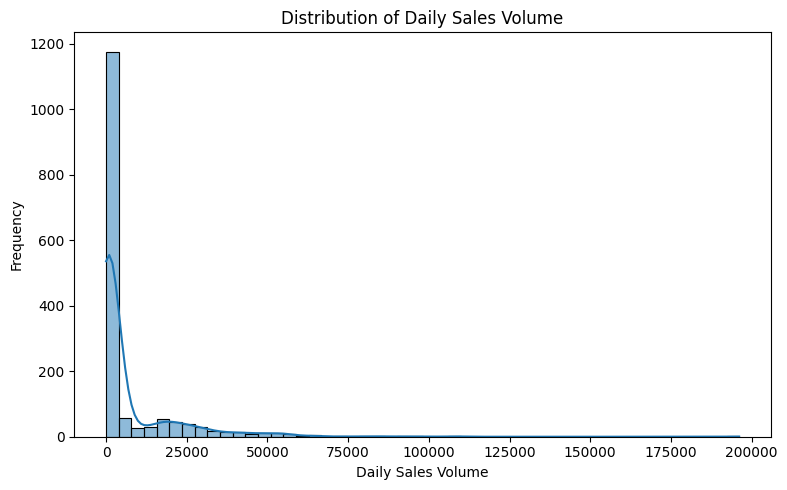

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_reg_final['daily_sales_volume'],
    bins=50,
    kde=True
)

plt.title('Distribution of Daily Sales Volume')
plt.xlabel('Daily Sales Volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Observation – Target Variable Distribution

The distribution of `daily_sales_volume` is strongly right-skewed. Most observations have relatively low daily sales volume, while a smaller number of observations have substantially higher values.

The distribution also shows a long right tail, with some daily sales volumes extending to very high values. This indicates considerable variation in the target variable and suggests that extreme values may need to be considered during preprocessing and model development.

## Distribution of Numerical Features

The distributions of the numerical predictor variables are examined individually to understand their spread and identify possible skewness or extreme values.

The numerical features considered are:
- `product_variation_count`
- `total_items_sold`
- `total_orders`

### Distribution of Product Variation Count

The distribution of `product_variation_count` is examined to understand the spread of the number of unique products sold across each Date–Country combination.

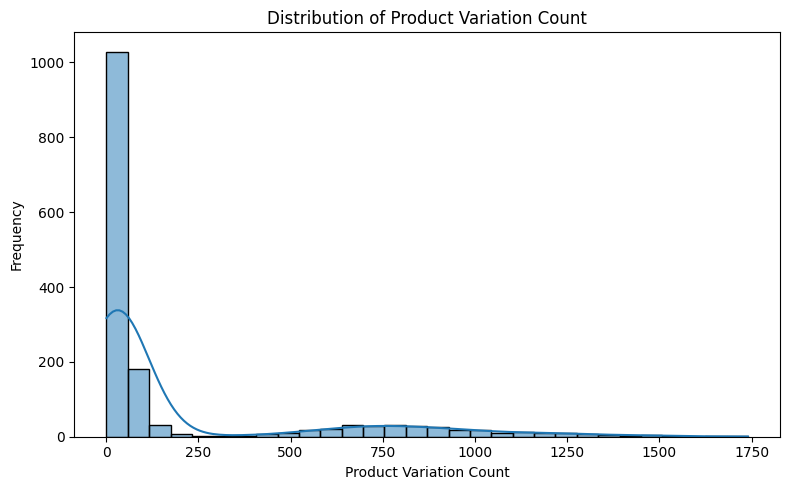

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_reg_final['product_variation_count'],
    bins=30,
    kde=True
)

plt.title('Distribution of Product Variation Count')
plt.xlabel('Product Variation Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Observation – Product Variation Count

The distribution of `product_variation_count` is concentrated at lower values, with fewer observations occurring at higher values.

The feature has a wide range of values, extending to approximately 1,750, and shows a long right tail.

### Distribution of Total Items Sold

The distribution of `total_items_sold` is examined to understand the spread of the total quantity of items sold across each Date–Country combination.

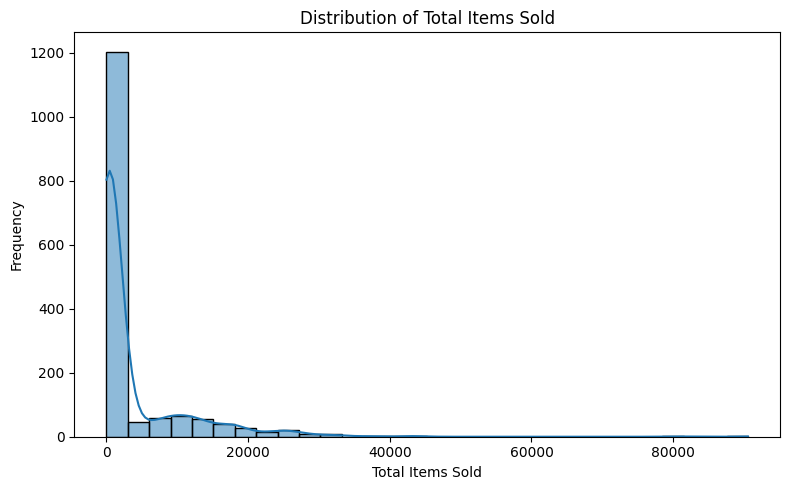

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_reg_final['total_items_sold'],
    bins=30,
    kde=True
)

plt.title('Distribution of Total Items Sold')
plt.xlabel('Total Items Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Observation – Total Items Sold

The distribution of `total_items_sold` is concentrated at lower values, while a smaller number of observations have substantially higher item counts.

The feature extends to approximately 90,000, resulting in a long right tail and a wide range of values.

### Distribution of Total Orders

The distribution of `total_orders` is examined to understand the spread of the number of unique orders across each Date–Country combination.

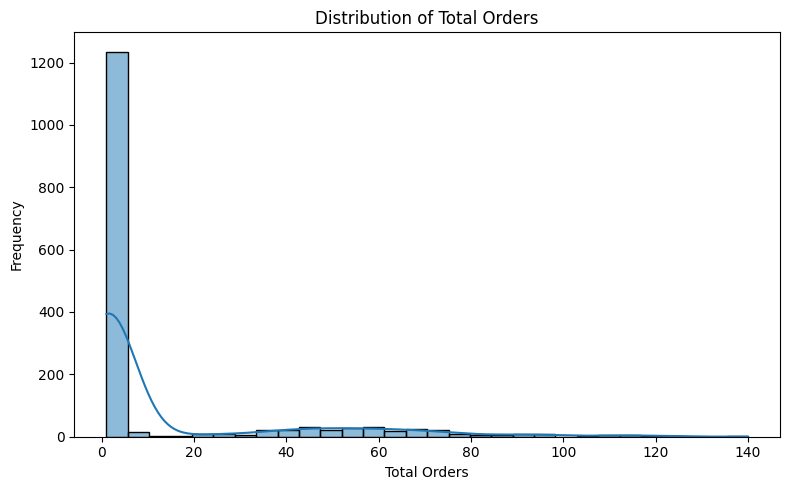

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_reg_final['total_orders'],
    bins=30,
    kde=True
)

plt.title('Distribution of Total Orders')
plt.xlabel('Total Orders')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Observation – Total Orders Distribution

The distribution of `total_orders` is concentrated at lower values, while a smaller number of observations occur at higher order counts.

The distribution extends over a relatively wide range, indicating variation in the number of orders across different Date–Country combinations.

### Distribution of Observations by Country

The `Country` feature represents the country associated with each Date–Country observation.

A bar plot is used to examine how the aggregated observations are distributed across different countries.

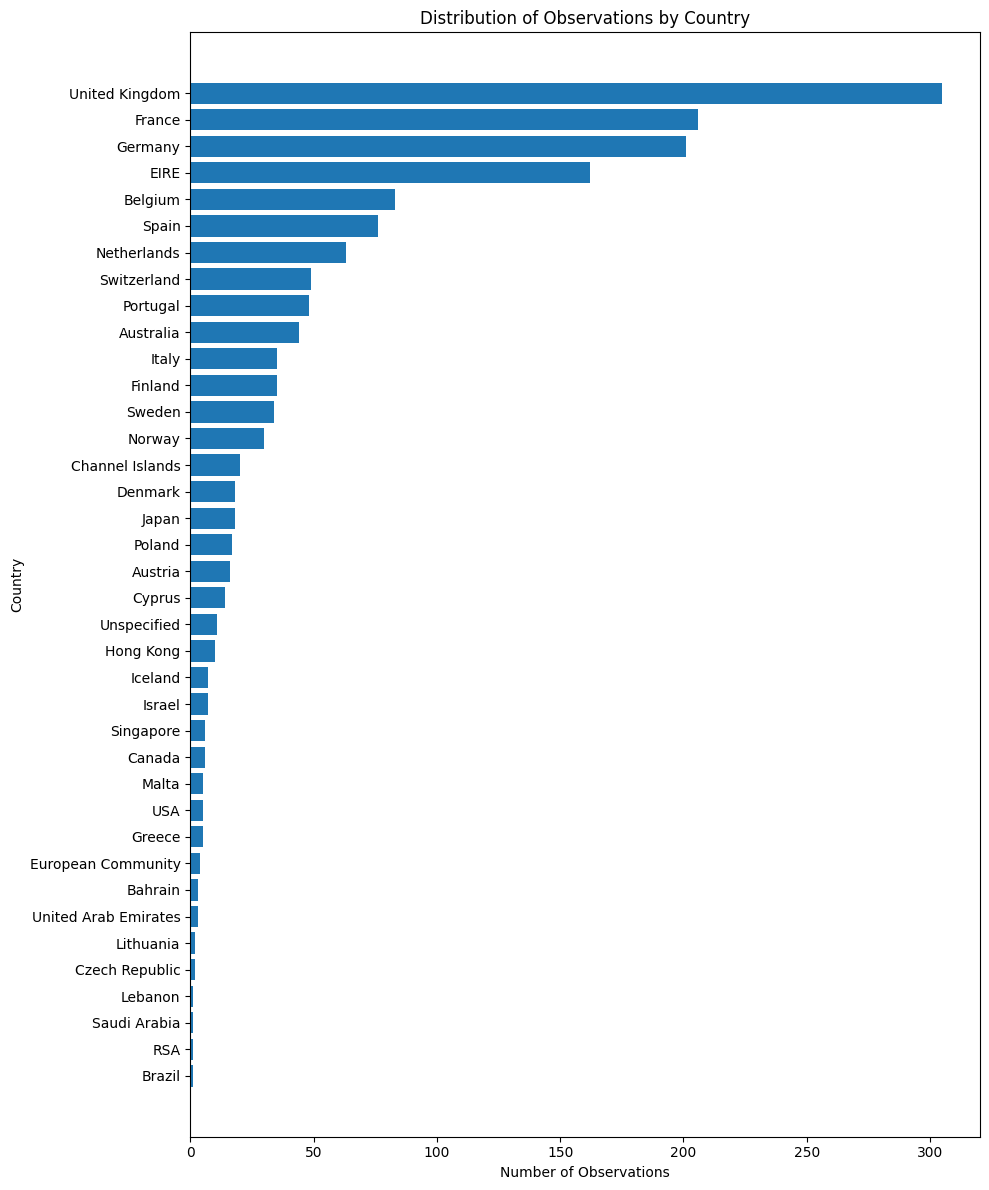

In [13]:
country_counts = df_reg_final['Country'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(
    country_counts.index,
    country_counts.values
)

plt.title('Distribution of Observations by Country')
plt.xlabel('Number of Observations')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#### Observation – Country Distribution

The number of Date–Country observations varies considerably across countries.

The United Kingdom has the highest number of observations, followed by France, Germany, and EIRE. Several other countries have substantially fewer observations.

### 2. Correlation Heatmap

A correlation heatmap is used to examine the linear relationships between the numerical features and the target variable.

The heatmap displays the correlation coefficient between each pair of numerical variables.

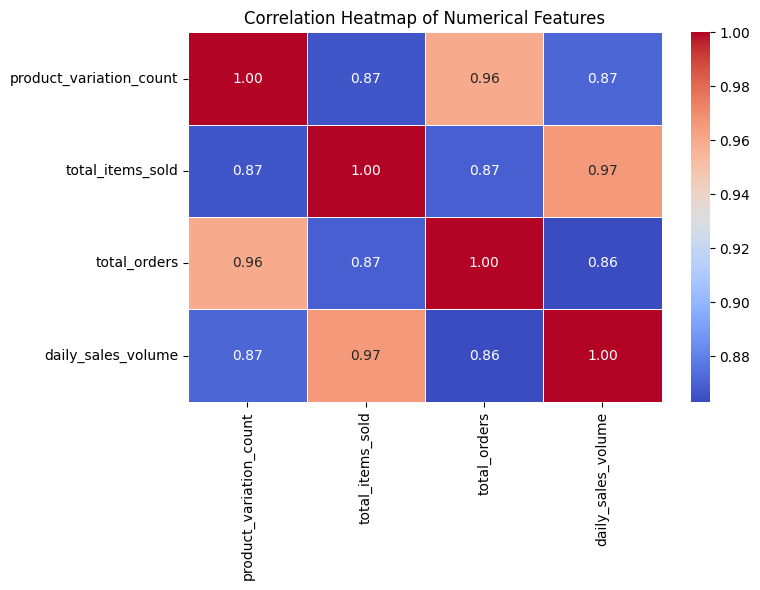

In [14]:
correlation_matrix = df_reg_final[
    [
        'product_variation_count',
        'total_items_sold',
        'total_orders',
        'daily_sales_volume'
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

#### Observation – Correlation Heatmap

The correlation heatmap shows positive linear relationships among all the numerical variables.

The target variable, `daily_sales_volume`, has correlation coefficients of 0.87 with `product_variation_count`, 0.97 with `total_items_sold`, and 0.86 with `total_orders`.

The predictor variables also show relatively high correlations with each other.

### 3. Total Items Sold vs Daily Sales Volume

A scatter plot is used to examine the relationship between `total_items_sold` and the target variable `daily_sales_volume`.

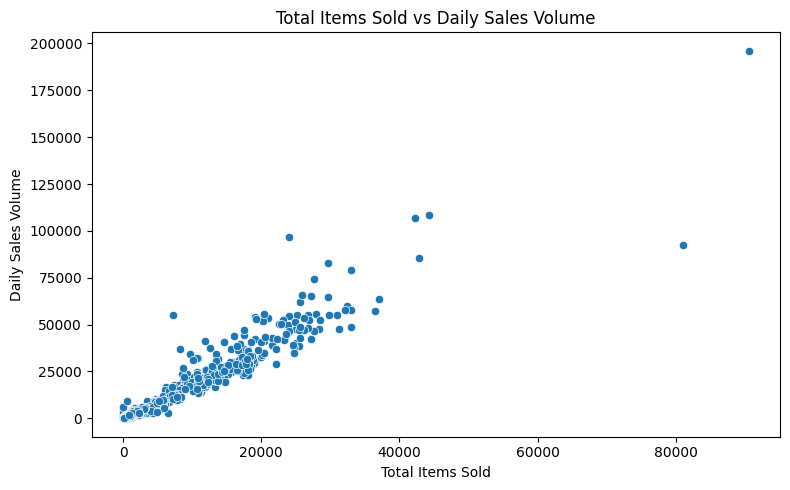

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_reg_final,
    x='total_items_sold',
    y='daily_sales_volume'
)

plt.title('Total Items Sold vs Daily Sales Volume')
plt.xlabel('Total Items Sold')
plt.ylabel('Daily Sales Volume')
plt.tight_layout()
plt.show()

#### Observation

The scatter plot shows the relationship### Observation – Total Items Sold vs Daily Sales Volume

The scatter plot shows a positive relationship between `total_items_sold` and `daily_sales_volume`. As the number of items sold increases, daily sales volume generally tends to increase.

Most observations are concentrated in the lower to middle ranges, while a few observations occur at substantially higher values. between product variety and daily sales volume. The points help us see whether sales generally increase when more product varieties are sold.

### 4. Total Orders vs Daily Sales

A scatter plot is used to examine the relationship between `total_orders` and the target variable `daily_sales_volume`.

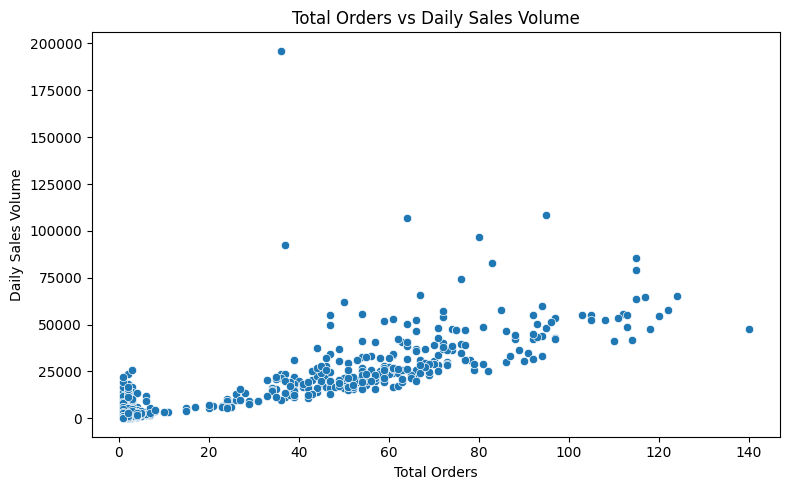

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_reg_final,
    x='total_orders',
    y='daily_sales_volume'
)

plt.title('Total Orders vs Daily Sales Volume')
plt.xlabel('Total Orders')
plt.ylabel('Daily Sales Volume')
plt.tight_layout()
plt.show()

#### Observation – Total Orders vs Daily Sales Volume

The scatter plot shows a positive relationship between `total_orders` and `daily_sales_volume`. In general, higher numbers of orders are associated with higher daily sales volume.

Most observations are concentrated in the lower to middle ranges, with a few observations showing substantially higher daily sales volumes.

### Overall EDA Observations

The EDA shows that `daily_sales_volume` and the numerical features are right-skewed, with most observations concentrated at lower values and a smaller number of higher values.

The country distribution is uneven, with the United Kingdom having the highest number of Date–Country observations.

The numerical features show strong positive correlations with the target. In particular, `total_items_sold` has the highest correlation with `daily_sales_volume` at **0.97**.

The scatter plots also show positive relationships between `total_items_sold`, `total_orders`, and `daily_sales_volume`.

These observations provide an initial understanding of the dataset before preprocessing and regression modeling.

## Section B: Preprocessing and Feature Engineering

In this section, we prepare the dataset for machine learning.

We will:
- Check and handle missing values
- Remove duplicate rows
- Convert the date into useful features
- Create a new feature
- Check and handle outliers
- Separate the features and target
- Split the data into training and testing sets
- Encode categorical features
- Scale numerical features

### Load the Data

First, we load the aggregated dataset that was created during the EDA step.

The target variable is `daily_sales_volume`, which is the value we want to predict.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

SEED = 42
TARGET = 'daily_sales_volume'
df = pd.read_csv(
    '../data/raw/data_1.csv',
    encoding='ISO-8859-1'
)

print("Original dataset shape:", df.shape)

Original dataset shape: (1554, 6)


### 1. Check Missing Values

Before cleaning the data, we check if any values are missing.

Missing values can cause problems when training a machine learning model, so they need to be handled properly.

In [18]:
df_reg_clean = df.copy()

print("\nMissing values before treatment:")
print(df_reg_clean.isnull().sum())


Missing values before treatment:
Date                       0
Country                    0
product_variation_count    0
total_items_sold           0
total_orders               0
daily_sales_volume         0
dtype: int64


### 2. Handle Missing Values

For numerical columns, missing values are replaced with the median value.

For categorical columns, missing values are replaced with `Unknown`.

This allows us to keep the available data instead of removing rows unnecessarily.

In [19]:
# Numerical columns -> median
numeric_cols = df_reg_clean.select_dtypes(
    include=[np.number]
).columns

for col in numeric_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            df_reg_clean[col].median()
        )

# Categorical columns -> Unknown
categorical_cols = df_reg_clean.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            'Unknown'
        )

print("Missing values after treatment:")
print(df_reg_clean.isnull().sum())

Missing values after treatment:
Date                       0
Country                    0
product_variation_count    0
total_items_sold           0
total_orders               0
daily_sales_volume         0
dtype: int64


### 3. Checking Duplicate Records

Duplicate records are checked in the final aggregated dataset to ensure that each Date–Country observation is unique before model development.

In [20]:
duplicate_count = df_reg_final.duplicated().sum()

print("--- DUPLICATE CHECK ---")
print(f"Number of duplicate rows: {duplicate_count}")

--- DUPLICATE CHECK ---
Number of duplicate rows: 0


### Remove Duplicate Rows

Duplicate rows contain the same information more than once.

We remove duplicate rows so that the same observation is not used multiple times.

In [21]:
# Duplicate removal
duplicates_count = df_reg_clean.duplicated().sum()

df_reg_clean = (
    df_reg_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDuplicate rows removed: {duplicates_count}")
print("Shape after cleaning:", df_reg_clean.shape)


Duplicate rows removed: 0
Shape after cleaning: (1554, 6)


### 4. Create Date Features

The `Date` column contains information about when the sales happened.

Instead of using the complete date directly, we create three simple features:

- `year` — the year of the sale
- `month` — the month of the sale
- `day_of_week` — the day of the week

These features can help the model learn seasonal and weekly patterns.

In [22]:
df_reg_clean['Date'] = pd.to_datetime(
    df_reg_clean['Date'],
    errors='coerce'
)

df_reg_clean['year'] = df_reg_clean['Date'].dt.year
df_reg_clean['month'] = df_reg_clean['Date'].dt.month
df_reg_clean['day_of_week'] = df_reg_clean['Date'].dt.dayofweek

df_reg_clean.drop(
    columns=['Date'],
    inplace=True
)

print("Date features created successfully.")
print(df_reg_clean[['year', 'month', 'day_of_week']].head())

Date features created successfully.
   year  month  day_of_week
0  2010     12            2
1  2010     12            2
2  2010     12            2
3  2010     12            2
4  2010     12            2


## Feature Engineering

Feature engineering involves creating a new feature from existing variables.

Here, `avg_items_per_order` is calculated by dividing `total_items_sold` by `total_orders`.

This feature represents the average number of items in each order for a particular country on a particular day.

In [23]:
# Create average items per order
df_reg_clean['avg_items_per_order'] = (
    df_reg_clean['total_items_sold'] /
    df_reg_clean['total_orders']
)

print("Created feature: avg_items_per_order")

Created feature: avg_items_per_order


## Remove Unnecessary Features

The `promotional_banner_count` feature is removed because it was created using random values and is not part of the original dataset.

The other useful features are kept for the regression models.

In [24]:
columns_to_remove = [
    'promotional_banner_count'
]

df_reg_clean.drop(
    columns=[
        col for col in columns_to_remove
        if col in df_reg_clean.columns
    ],
    inplace=True
)

print("\nRemoved redundant/synthetic features:")
print([
    col for col in columns_to_remove
    if col in df.columns
])


Removed redundant/synthetic features:
[]


## Separate Features and Target

The target is the value that we want the model to predict.

Here, the target is `daily_sales_volume`.

All the other columns are used as input features.

In [25]:
X = df_reg_clean.drop(
    columns=[TARGET]
)

# Keep the original target for final evaluation
y_original = df_reg_clean[TARGET].clip(lower=0)

print("Features shape:", X.shape)
print("Target shape:", y_original.shape)

Features shape: (1554, 8)
Target shape: (1554,)


## Transform the Target Variable

Daily sales volume can have some very large values.

We use a log transformation to reduce the effect of these very large values and make the target easier for the models to learn.

In [26]:
y = np.log1p(y_original)

print("Target transformation completed.")

Target transformation completed.


## Train-Test Split

We divide the data into two parts:

- **80% training data** — used to train the models
- **20% testing data** — used to evaluate the models

We use stratification so that the training and testing sets have a similar distribution of the target values.

In [27]:
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

(
    X_train,
    X_test,
    y_train,
    y_test,
    y_train_original,
    y_test_original
) = train_test_split(
    X,
    y,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bins
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Train/Test split:
X_train: (1243, 8)
X_test : (311, 8)
y_train: (1243,)
y_test : (311,)


### Train-Test Split Verification

The dataset is divided into training and testing sets using an 80:20 split.

A fixed random seed of 42 is used to ensure reproducibility, and stratification is applied based on target-value bins to maintain a similar target distribution in both sets.

In [28]:
print("--- TRAIN-TEST SPLIT ---")

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")

print(
    f"Training ratio: "
    f"{len(X_train) / len(X) * 100:.1f}%"
)

print(
    f"Testing ratio: "
    f"{len(X_test) / len(X) * 100:.1f}%"
)

--- TRAIN-TEST SPLIT ---
Training samples: 1,243
Testing samples : 311
Training ratio: 80.0%
Testing ratio: 20.0%


### Check and Handle Outliers

An outlier is a value that is much higher or lower than most other values.

We use the IQR method to find unusual values in the continuous feature.

The limits are calculated using only the training data. This prevents information from the test data from affecting the training process.

In [29]:
continuous_features = [
    'product_variation_count',
    'total_items_sold',
    'total_orders',
    'avg_items_per_order'
]

outlier_bounds = {}

print("\nPredictor outlier audit:")

for col in continuous_features:

    if col not in X_train.columns:
        continue

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = (lower, upper)

    count = (
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ).sum()

    print(
        f"{col}: {count} outliers "
        f"[{lower:.2f}, {upper:.2f}]"
    )

    # Apply training-derived bounds
    X_train[col] = X_train[col].clip(
        lower,
        upper
    )

    X_test[col] = X_test[col].clip(
        lower,
        upper
    )



Predictor outlier audit:
product_variation_count: 243 outliers [-96.00, 200.00]
total_items_sold: 255 outliers [-2673.00, 4967.00]


total_orders: 247 outliers [-2.00, 6.00]
avg_items_per_order: 127 outliers [-196.00, 724.00]


### Check Target Outliers

We also check for unusual values in the target variable.

The outlier limits are calculated using the training target only.

We then limit the training target values to these limits.

The test target is left unchanged because it should represent the real data used for final evaluation.

In [30]:
# Calculate bounds using training target only
Q1_y = y_train.quantile(0.25)
Q3_y = y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

target_outliers = (
    (y_train < lower_y) |
    (y_train > upper_y)
).sum()

print(
    f"\nTarget outliers in training data: "
    f"{target_outliers}"
)

print(
    f"Target IQR bounds: "
    f"[{lower_y:.4f}, {upper_y:.4f}]"
)

# Cap training target only
y_train = y_train.clip(
    lower_y,
    upper_y
)


Target outliers in training data: 6
Target IQR bounds: [2.5977, 11.5446]


## Identify Feature Types

Machine learning models handle numerical and categorical data differently.

We separate the columns into two groups:

- Numerical features
- Categorical features

In [31]:
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Categorical features:
['Country']

Numerical features:
['product_variation_count', 'total_items_sold', 'total_orders', 'year', 'month', 'day_of_week', 'avg_items_per_order']


## Handle Rare Countries

Some countries may have very few records.

We group countries that appear fewer than 5 times into `Other`.

The country counts are calculated using the training data only.

In [32]:
if 'Country' in X_train.columns:

    country_counts = X_train['Country'].value_counts()

    rare_countries = country_counts[
        country_counts < 5
    ].index

    X_train['Country'] = X_train['Country'].replace(
        rare_countries,
        'Other'
    )

    X_test['Country'] = X_test['Country'].replace(
        rare_countries,
        'Other'
    )

    print(
        "Rare countries grouped into 'Other':",
        len(rare_countries)
    )

Rare countries grouped into 'Other': 10


## Encoding and Scaling

Machine learning models work better when the input data is prepared properly.

For numerical features, we use `StandardScaler` to put the values on a similar scale.

For categorical features, we use `OneHotEncoder` to convert categories into numerical values.

The encoder and scaler are fitted only on the training data.

In [33]:
# Update feature lists after handling rare countries
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

### Fit the Preprocessor on Training Data

The scaler and encoder are fitted using only the training data.

The test data is only transformed using the information learned from the training data.

This helps prevent data leakage.

In [34]:
# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform test using training parameters
X_test_processed = preprocessor.transform(
    X_test
)

c:\Users\muthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Create the Final Processed Data

After encoding and scaling, we convert the results back into DataFrames.

This makes the processed data easier to view and use in the next section.

In [35]:
feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_scaled = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data:", X_train_scaled.shape)
print("Processed testing data :", X_test_scaled.shape)

Processed training data: (1243, 33)
Processed testing data : (311, 33)


## Final Preprocessing Check

Finally, we check the processed data.

We make sure that:
- The train and test data have the expected sizes.
- There are no missing values.
- The final features are ready for model training.

In [36]:
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)

print("\nFinal shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train_scaled.isnull().sum().sum())
print("X_test :", X_test_scaled.isnull().sum().sum())
print("y_train:", y_train.isnull().sum())
print("y_test :", y_test.isnull().sum())

print("\nFinal features:")
print(X_train_scaled.columns.tolist())

print("\nPreprocessing completed successfully.")

PREPROCESSING COMPLETE

Final shapes:
X_train_scaled: (1243, 33)
X_test_scaled : (311, 33)
y_train       : (1243,)
y_test        : (311,)

Missing values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0

Final features:
['num__product_variation_count', 'num__total_items_sold', 'num__total_orders', 'num__year', 'num__month', 'num__day_of_week', 'num__avg_items_per_order', 'cat__Country_Austria', 'cat__Country_Belgium', 'cat__Country_Canada', 'cat__Country_Channel Islands', 'cat__Country_Cyprus', 'cat__Country_Denmark', 'cat__Country_EIRE', 'cat__Country_Finland', 'cat__Country_France', 'cat__Country_Germany', 'cat__Country_Hong Kong', 'cat__Country_Iceland', 'cat__Country_Israel', 'cat__Country_Italy', 'cat__Country_Japan', 'cat__Country_Netherlands', 'cat__Country_Norway', 'cat__Country_Other', 'cat__Country_Poland', 'cat__Country_Portugal', 'cat__Country_Singapore', 'cat__Country_Spain', 'cat__Country_Sweden', 'cat__Country_Switzerland', 'cat__Country_United Kingdom', 'cat__Country_Unspec

In [37]:
from pathlib import Path

script_dir = Path.cwd()
train_processed = X_train_scaled.copy()
train_processed['target'] = y_train.values

test_processed = X_test_scaled.copy()
test_processed['target'] = y_test.values

train_path = script_dir.parent / "data" / "processed" / "train_processed.csv"
test_path = script_dir.parent / "data" / "processed" / "test_processed.csv"

train_processed.to_csv(
    '../data/processed/train_processed.csv',
    index=False
)

test_processed.to_csv(
    '../data/processed/test_processed.csv',
    index=False
)

print("Processed training and testing data saved successfully.")

Processed training and testing data saved successfully.


## Section C. Regression Track

Multiple regression algorithms are trained and evaluated using the same preprocessed training and testing datasets.

The following 10 regression algorithms are considered:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regression
7. Random Forest Regression
8. Gradient Boosting Regression
9. Support Vector Regression (SVR)
10. K-Nearest Neighbors (KNN) Regression

## Import Regression Algorithms

The required regression algorithms and evaluation metrics are imported from Scikit-learn.

The models will be trained using the preprocessed training data created in Section B.

In [38]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## 1. Linear Regression

Linear Regression is used as the baseline model.

y=b0​+b1​x1​+b2​x2​+⋯+bn​xn​

where:

- y = predicted target
- x1,x2,.. = features
- b0 = intercept
- bi = coefficients

It tries to find a linear relationship between the input features and the target variable `daily_sales_volume`.

In [39]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred_log = linear_model.predict(X_test_scaled)

linear_pred = np.expm1(linear_pred_log)
linear_pred = np.maximum(linear_pred, 0)

linear_r2 = r2_score(y_test_original, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test_original, linear_pred))
linear_mae = mean_absolute_error(y_test_original, linear_pred)

print("Linear Regression")
print("R2   :", round(linear_r2, 4))
print("RMSE :", round(linear_rmse, 4))
print("MAE  :", round(linear_mae, 4))

Linear Regression
R2   : 0.8427
RMSE : 4758.5432
MAE  : 1993.7796


## 2. Ridge Regression

Ridge Regression is similar to Linear Regression but adds L2 regularisation.

Loss=MSE+α j=1∑ n​βj2​

where:

- α = regularization strength
- β = model coefficients

Regularisation helps reduce the effect of very large coefficients and can improve model stability.

In [40]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred_log = ridge_model.predict(X_test_scaled)

ridge_pred = np.expm1(ridge_pred_log)
ridge_pred = np.maximum(ridge_pred, 0)

ridge_r2 = r2_score(y_test_original, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test_original, ridge_pred))
ridge_mae = mean_absolute_error(y_test_original, ridge_pred)

print("Ridge Regression")
print("R2   :", round(ridge_r2, 4))
print("RMSE :", round(ridge_rmse, 4))
print("MAE  :", round(ridge_mae, 4))

Ridge Regression
R2   : 0.8427
RMSE : 4759.9168
MAE  : 1992.158


## 3. Lasso Regression

Lasso Regression uses L1 regularisation.

Loss=MSE+αj=1∑n​∣βj​|



It can reduce some model coefficients towards zero, which can help simplify the model.

In [41]:
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred_log = lasso_model.predict(X_test_scaled)

lasso_pred = np.expm1(lasso_pred_log)
lasso_pred = np.maximum(lasso_pred, 0)

lasso_r2 = r2_score(y_test_original, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test_original, lasso_pred))
lasso_mae = mean_absolute_error(y_test_original, lasso_pred)

print("Lasso Regression")
print("R2   :", round(lasso_r2, 4))
print("RMSE :", round(lasso_rmse, 4))
print("MAE  :", round(lasso_mae, 4))

Lasso Regression
R2   : 0.834
RMSE : 4888.6524
MAE  : 1983.814


## 4. ElasticNet Regression

ElasticNet combines L1 and L2 regularisation.

It can provide a balance between the properties of Lasso and Ridge Regression.

Loss=MSE+α[l1_ratio∑∣βj​∣+(1−l1_ratio)∑βj2​]

In [42]:
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred_log = elastic_model.predict(X_test_scaled)

elastic_pred = np.expm1(elastic_pred_log)
elastic_pred = np.maximum(elastic_pred, 0)

elastic_r2 = r2_score(y_test_original, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test_original, elastic_pred))
elastic_mae = mean_absolute_error(y_test_original, elastic_pred)

print("ElasticNet Regression")
print("R2   :", round(elastic_r2, 4))
print("RMSE :", round(elastic_rmse, 4))
print("MAE  :", round(elastic_mae, 4))

ElasticNet Regression
R2   : 0.8373
RMSE : 4840.6615
MAE  : 1977.2514


## 5. Polynomial Regression – Initial Approach

Polynomial Regression extends Linear Regression by creating polynomial features.

This allows the model to learn non-linear relationships between the input features and the target.

We start with degree 2 and will compare different polynomial degrees separately.

y=b0​+b1​x+b2​x2

In [43]:
polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

polynomial_model.fit(X_train_scaled, y_train)

polynomial_pred_log = polynomial_model.predict(X_test_scaled)

polynomial_pred = np.expm1(polynomial_pred_log)
polynomial_pred = np.maximum(polynomial_pred, 0)

polynomial_r2 = r2_score(
    y_test_original,
    polynomial_pred
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        polynomial_pred
    )
)

polynomial_mae = mean_absolute_error(
    y_test_original,
    polynomial_pred
)

print("Polynomial Regression (Initial Approach) - Degree 2")
print("R2   :", round(polynomial_r2, 4))
print("RMSE :", round(polynomial_rmse, 4))
print("MAE  :", round(polynomial_mae, 4))

Polynomial Regression (Initial Approach) - Degree 2
R2   : -3712565661.6071
RMSE : 731160223.7949
MAE  : 41462325.8989


### Refinement of Polynomial Regression

The initial Polynomial Regression approach applied polynomial expansion to all preprocessed features, including the one-hot encoded categorical variables.

This resulted in a very large feature space because polynomial expansion also creates interaction terms between features. Therefore, the approach was refined by applying polynomial expansion only to the numerical features, while keeping the encoded country features unchanged.

This provides a more controlled polynomial feature space and allows the effect of the numerical variables to be modeled through polynomial and interaction terms.

In [44]:
from sklearn.compose import ColumnTransformer

# Select all numerical columns
poly_numeric_features = [
    'num__product_variation_count',
    'num__total_items_sold',
    'num__total_orders',
    'num__year',
    'num__month',
    'num__day_of_week',
    'num__avg_items_per_order'
]

# Select categorical columns
categorical_features = [
    col for col in X_train_scaled.columns
    if col.startswith('cat__')
]

# Create polynomial features only for numerical variables
poly_transformer = ColumnTransformer(
    transformers=[
        (
            'polynomial',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            poly_numeric_features
        )
    ],
    remainder='passthrough'
)

# Polynomial Regression model
polynomial_model = Pipeline([
    ('polynomial_features', poly_transformer),
    ('linear_regression', LinearRegression())
])

# Train
polynomial_model.fit(X_train_scaled, y_train)

# Predict
polynomial_pred_log = polynomial_model.predict(X_test_scaled)

# Convert predictions back from log scale
polynomial_pred = np.expm1(polynomial_pred_log)
polynomial_pred = np.maximum(polynomial_pred, 0)

# Evaluate
polynomial_r2 = r2_score(
    y_test_original,
    polynomial_pred
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        polynomial_pred
    )
)

polynomial_mae = mean_absolute_error(
    y_test_original,
    polynomial_pred
)

print("Polynomial Regression (Corrected) - Degree 2")
print("R2   :", round(polynomial_r2, 4))
print("RMSE :", round(polynomial_rmse, 4))
print("MAE  :", round(polynomial_mae, 4))

Polynomial Regression (Corrected) - Degree 2
R2   : 0.8658
RMSE : 4395.7077
MAE  : 1748.6771


### Selected Features for Polynomial Expansion

Based on the initial approach, polynomial expansion is applied only to the numerical features.

The selected features are:

- `product_variation_count`
- `total_items_sold`
- `total_orders`
- `year`
- `month`
- `day_of_week`
- `avg_items_per_order`

The categorical country features are not polynomially expanded and are passed through unchanged.

This selection reduces unnecessary feature expansion while still allowing polynomial and interaction terms among the numerical variables.

## Regression Model Comparison

The five regression models are compared using three evaluation metrics:

- **R²**: Measures how well the model explains the variation in the target.
- **RMSE**: Measures the average prediction error, with larger errors receiving more weight.
- **MAE**: Measures the average absolute prediction error.

The models are ranked based on R², with the highest R² ranked first.

In [45]:
results = [
    {
        "Model": "Linear Regression",
        "R2": linear_r2,
        "RMSE": linear_rmse,
        "MAE": linear_mae
    },
    {
        "Model": "Ridge Regression",
        "R2": ridge_r2,
        "RMSE": ridge_rmse,
        "MAE": ridge_mae
    },
    {
        "Model": "Lasso Regression",
        "R2": lasso_r2,
        "RMSE": lasso_rmse,
        "MAE": lasso_mae
    },
    {
        "Model": "ElasticNet Regression",
        "R2": elastic_r2,
        "RMSE": elastic_rmse,
        "MAE": elastic_mae
    },
    {
        "Model": "Polynomial Regression",
        "R2": polynomial_r2,
        "RMSE": polynomial_rmse,
        "MAE": polynomial_mae
    }
]

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_df.insert(
    0,
    "Rank",
    range(1, len(comparison_df) + 1)
)

display(
    comparison_df.style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.2f}",
        "MAE": "{:.2f}"
    })
)

,Rank,Model,R2,RMSE,MAE
0,1,Polynomial Regression,0.8658,4395.71,1748.68
1,2,Linear Regression,0.8427,4758.54,1993.78
2,3,Ridge Regression,0.8427,4759.92,1992.16
3,4,ElasticNet Regression,0.8373,4840.66,1977.25
4,5,Lasso Regression,0.8340,4888.65,1983.81


### Best Performing Model

The model with the highest R² score is considered the best-performing model among these five algorithms.

The final model selection will be made after all required regression algorithms are evaluated and compared.

In [46]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Best model among the first five:", best_model_name)
print("R2 score:", round(comparison_df.iloc[0]["R2"], 4))

Best model among the first five: Polynomial Regression
R2 score: 0.8658


## R² Comparison of the First Five Models

The R² scores of the five regression models are visualised below.

A higher R² value indicates better performance.

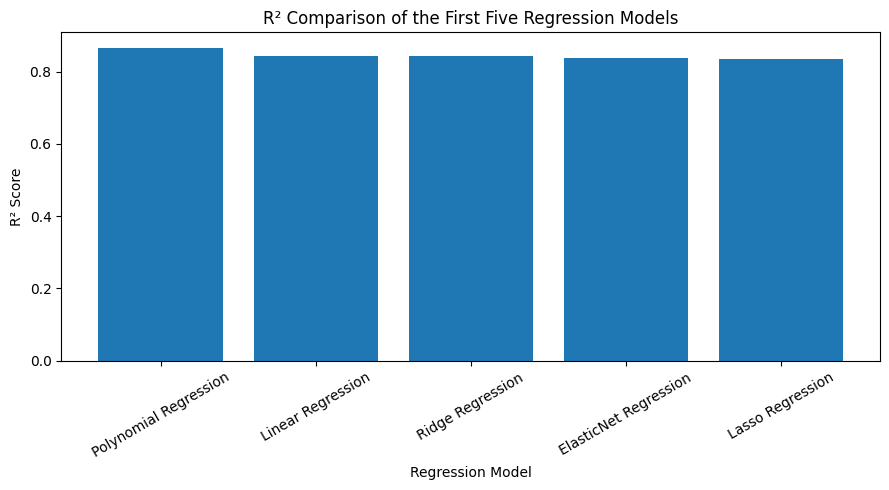

In [47]:
plt.figure(figsize=(9, 5))

plt.bar(comparison_df["Model"], comparison_df["R2"])

plt.title("R² Comparison of the First Five Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation

The bar chart compares the R² scores of the five regression models.

The model with the highest R² performs best among these five models.

## Polynomial Regression Degree Comparison

Polynomial Regression can use different polynomial degrees.

Here, Degree 2 and Degree 3 are compared using polynomial features for the numerical variables only. The categorical country features are kept unchanged.

This comparison helps determine whether increasing the polynomial degree improves model performance.

In [48]:
polynomial_results = []

for degree in [2, 3]:

    # Apply polynomial transformation only to numerical features
    poly_transformer = ColumnTransformer(
        transformers=[
            (
                'polynomial',
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                ),
                poly_numeric_features
            )
        ],
        remainder='passthrough'
    )

    # Create polynomial regression pipeline
    model = Pipeline([
        (
            'polynomial_features',
            poly_transformer
        ),
        (
            'linear_regression',
            LinearRegression()
        )
    ])

    # Train the model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Predict
    pred_log = model.predict(
        X_test_scaled
    )

    # Convert predictions back to original scale
    pred = np.expm1(pred_log)
    pred = np.maximum(pred, 0)

    # Calculate metrics
    r2 = r2_score(
        y_test_original,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test_original,
        pred
    )

    polynomial_results.append({
        'Degree': degree,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })


degree_comparison_df = pd.DataFrame(
    polynomial_results
)

display(
    degree_comparison_df.style.format({
        'R2': '{:.4f}',
        'RMSE': '{:.2f}',
        'MAE': '{:.2f}'
    })
)

,Degree,R2,RMSE,MAE
0,2,0.8658,4395.71,1748.68
1,3,0.8214,5071.13,1872.75


## Polynomial Degree Comparison Graph

The R² scores for the different polynomial degrees are shown below.

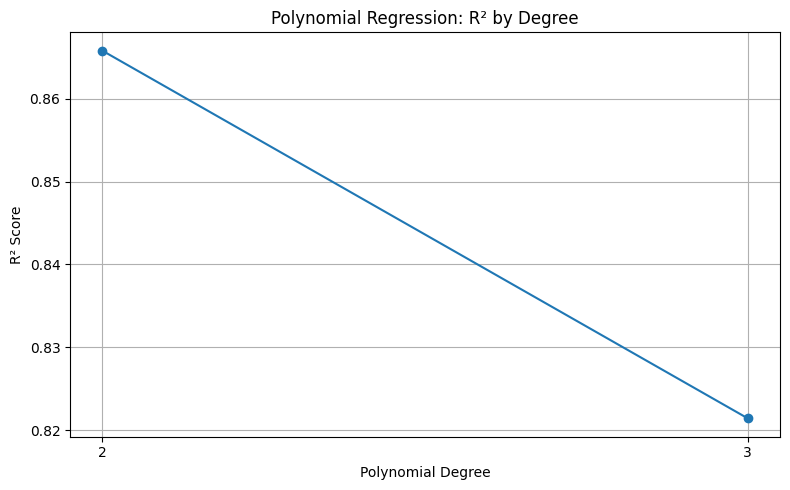

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    degree_comparison_df['Degree'],
    degree_comparison_df['R2'],
    marker='o'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Regression: R² by Degree')

plt.xticks([2, 3])
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
print(X_train_scaled.columns.tolist())

['num__product_variation_count', 'num__total_items_sold', 'num__total_orders', 'num__year', 'num__month', 'num__day_of_week', 'num__avg_items_per_order', 'cat__Country_Austria', 'cat__Country_Belgium', 'cat__Country_Canada', 'cat__Country_Channel Islands', 'cat__Country_Cyprus', 'cat__Country_Denmark', 'cat__Country_EIRE', 'cat__Country_Finland', 'cat__Country_France', 'cat__Country_Germany', 'cat__Country_Hong Kong', 'cat__Country_Iceland', 'cat__Country_Israel', 'cat__Country_Italy', 'cat__Country_Japan', 'cat__Country_Netherlands', 'cat__Country_Norway', 'cat__Country_Other', 'cat__Country_Poland', 'cat__Country_Portugal', 'cat__Country_Singapore', 'cat__Country_Spain', 'cat__Country_Sweden', 'cat__Country_Switzerland', 'cat__Country_United Kingdom', 'cat__Country_Unspecified']


### Hyperparameter Tuning

In [51]:
from sklearn.model_selection import GridSearchCV

### Hyperparameter Tuning – Ridge Regression

Ridge Regression uses L2 regularization to reduce the effect of large model coefficients.

The `alpha` parameter controls the strength of regularization. GridSearchCV is used to evaluate different alpha values using 5-fold cross-validation and select the value with the best cross-validation R² score.

In [52]:
ridge = Ridge()

ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge parameters:")
print(ridge_grid.best_params_)

print("Best CV R²:")
print(round(ridge_grid.best_score_, 4))

Best Ridge parameters:
{'alpha': 10}
Best CV R²:
0.9076


In [53]:
ridge_tuned_pred_log = ridge_grid.best_estimator_.predict(X_test_scaled)

ridge_tuned_pred = np.expm1(ridge_tuned_pred_log)
ridge_tuned_pred = np.clip(ridge_tuned_pred, 0, None)

ridge_tuned_r2 = r2_score(
    y_test_original,
    ridge_tuned_pred
)

ridge_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        ridge_tuned_pred
    )
)

ridge_tuned_mae = mean_absolute_error(
    y_test_original,
    ridge_tuned_pred
)

print("Tuned Ridge Regression")
print("R²:", round(ridge_tuned_r2, 4))
print("RMSE:", round(ridge_tuned_rmse, 4))
print("MAE:", round(ridge_tuned_mae, 4))

Tuned Ridge Regression
R²: 0.842
RMSE: 4769.3905
MAE: 1980.4073


### Hyperparameter Tuning – ElasticNet Regression

ElasticNet combines L1 and L2 regularization.

The `alpha` parameter controls the overall regularization strength, while `l1_ratio` controls the balance between L1 and L2 regularization.

GridSearchCV is used to evaluate different combinations of these parameters using 5-fold cross-validation.

In [54]:
elastic_net = ElasticNet(
    max_iter=10000
)

elastic_net_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_net_grid = GridSearchCV(
    estimator=elastic_net,
    param_grid=elastic_net_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

elastic_net_grid.fit(X_train_scaled, y_train)

print("Best ElasticNet parameters:")
print(elastic_net_grid.best_params_)

print("Best CV R²:")
print(round(elastic_net_grid.best_score_, 4))

Best ElasticNet parameters:
{'alpha': 0.01, 'l1_ratio': 0.9}
Best CV R²:
0.9077


In [55]:
elastic_net_tuned_pred_log = (
    elastic_net_grid.best_estimator_.predict(X_test_scaled)
)

elastic_net_tuned_pred = np.expm1(
    elastic_net_tuned_pred_log
)

elastic_net_tuned_pred = np.clip(
    elastic_net_tuned_pred,
    0,
    None
)

elastic_net_tuned_r2 = r2_score(
    y_test_original,
    elastic_net_tuned_pred
)

elastic_net_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        elastic_net_tuned_pred
    )
)

elastic_net_tuned_mae = mean_absolute_error(
    y_test_original,
    elastic_net_tuned_pred
)

print("Tuned ElasticNet Regression")
print("R²:", round(elastic_net_tuned_r2, 4))
print("RMSE:", round(elastic_net_tuned_rmse, 4))
print("MAE:", round(elastic_net_tuned_mae, 4))

Tuned ElasticNet Regression
R²: 0.8347
RMSE: 4879.2658
MAE: 1981.4825


### Lasso Hyperparameter Tuning

Lasso Regression uses L1 regularization to control model complexity and can reduce the influence of less important features by shrinking their coefficients toward zero.

GridSearchCV with 5-fold cross-validation is used to find the value of `alpha` that gives the highest cross-validation R².

In [56]:
# Hyperparameter tuning for Lasso Regression

lasso = Lasso(max_iter=10000)

lasso_param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso parameters:", lasso_grid.best_params_)
print("Best CV R²:", round(lasso_grid.best_score_, 4))

Best Lasso parameters: {'alpha': 0.01}
Best CV R²: 0.9077


In [57]:
# Evaluate the tuned Lasso model on the held-out test set

tuned_lasso = lasso_grid.best_estimator_

y_pred_lasso_tuned_log = tuned_lasso.predict(X_test_scaled)
y_pred_lasso_tuned = np.expm1(y_pred_lasso_tuned_log)
y_pred_lasso_tuned = np.clip(y_pred_lasso_tuned, 0, None)

lasso_tuned_r2 = r2_score(
    y_test_original,
    y_pred_lasso_tuned
)

lasso_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_lasso_tuned
    )
)

lasso_tuned_mae = mean_absolute_error(
    y_test_original,
    y_pred_lasso_tuned
)

print("Tuned Lasso Test R²:", round(lasso_tuned_r2, 4))
print("Tuned Lasso Test RMSE:", round(lasso_tuned_rmse, 4))
print("Tuned Lasso Test MAE:", round(lasso_tuned_mae, 4))

Tuned Lasso Test R²: 0.834
Tuned Lasso Test RMSE: 4888.6524
Tuned Lasso Test MAE: 1983.814


## 6. Decision Tree Regressor

Decision Tree Regression predicts the target by splitting the data into smaller groups based on feature values.

It can capture non-linear relationships between the features and `daily_sales_volume`.

In [58]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(random_state=42)

decision_tree_model.fit(X_train_scaled, y_train)

decision_tree_pred_log = decision_tree_model.predict(X_test_scaled)

decision_tree_pred = np.expm1(decision_tree_pred_log)
decision_tree_pred = np.maximum(decision_tree_pred, 0)

decision_tree_r2 = r2_score(y_test_original, decision_tree_pred)
decision_tree_rmse = np.sqrt(mean_squared_error(y_test_original, decision_tree_pred))
decision_tree_mae = mean_absolute_error(y_test_original, decision_tree_pred)

print("Decision Tree Regressor")
print("R2   :", round(decision_tree_r2, 4))
print("RMSE :", round(decision_tree_rmse, 4))
print("MAE  :", round(decision_tree_mae, 4))

Decision Tree Regressor
R2   : 0.7711
RMSE : 5740.8976
MAE  : 2071.0659


### Feature Importance

Decision Trees can show how much each feature contributed to the model predictions.

In [59]:
decision_tree_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(
    decision_tree_importance.head(10).style.format({
        "Importance": "{:.4f}"
    })
)

,Feature,Importance
1,num__total_items_sold,0.9199
6,num__avg_items_per_order,0.0177
0,num__product_variation_count,0.0173
4,num__month,0.0114
2,num__total_orders,0.0086
5,num__day_of_week,0.0074
27,cat__Country_Singapore,0.0037
13,cat__Country_EIRE,0.0028
31,cat__Country_United Kingdom,0.0021
23,cat__Country_Norway,0.0016


## 7. Random Forest Regressor

Random Forest Regression combines multiple decision trees and averages their predictions.

This ensemble approach can capture complex relationships while reducing the dependence on a single decision tree.

In [60]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_scaled, y_train)

random_forest_pred_log = random_forest_model.predict(X_test_scaled)

random_forest_pred = np.expm1(random_forest_pred_log)
random_forest_pred = np.maximum(random_forest_pred, 0)

random_forest_r2 = r2_score(y_test_original, random_forest_pred)
random_forest_rmse = np.sqrt(mean_squared_error(y_test_original, random_forest_pred))
random_forest_mae = mean_absolute_error(y_test_original, random_forest_pred)

print("Random Forest Regressor")
print("R2   :", round(random_forest_r2, 4))
print("RMSE :", round(random_forest_rmse, 4))
print("MAE  :", round(random_forest_mae, 4))

Random Forest Regressor
R2   : 0.8786
RMSE : 4180.9841
MAE  : 1564.378


## 8. Gradient Boosting Regressor

Gradient Boosting Regression builds trees sequentially, where each new tree tries to improve the errors made by the previous trees.

It can model non-linear relationships and interactions between features.

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)

gradient_boosting_model.fit(X_train_scaled, y_train)

gradient_boosting_pred_log = gradient_boosting_model.predict(X_test_scaled)

gradient_boosting_pred = np.expm1(gradient_boosting_pred_log)
gradient_boosting_pred = np.maximum(gradient_boosting_pred, 0)

gradient_boosting_r2 = r2_score(y_test_original, gradient_boosting_pred)
gradient_boosting_rmse = np.sqrt(mean_squared_error(y_test_original, gradient_boosting_pred))
gradient_boosting_mae = mean_absolute_error(y_test_original, gradient_boosting_pred)

print("Gradient Boosting Regressor")
print("R2   :", round(gradient_boosting_r2, 4))
print("RMSE :", round(gradient_boosting_rmse, 4))
print("MAE  :", round(gradient_boosting_mae, 4))

Gradient Boosting Regressor
R2   : 0.8632
RMSE : 4438.787
MAE  : 1688.1401


## 9. Support Vector Regressor (SVR)

Support Vector Regression tries to find a function that predicts the target while allowing a controlled amount of error.

SVR is sensitive to feature scale, so the preprocessed and scaled features are used for training.

In [62]:
from sklearn.svm import SVR

svr_model = SVR(
    C=1.0,
    kernel="rbf"
)

svr_model.fit(X_train_scaled, y_train)

svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
svr_pred = np.maximum(svr_pred, 0)

svr_r2 = r2_score(y_test_original, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_original, svr_pred))
svr_mae = mean_absolute_error(y_test_original, svr_pred)

print("Support Vector Regressor")
print("R2   :", round(svr_r2, 4))
print("RMSE :", round(svr_rmse, 4))
print("MAE  :", round(svr_mae, 4))

Support Vector Regressor
R2   : 0.8964
RMSE : 3861.6551
MAE  : 1588.0958


## 10. K-Nearest Neighbors Regressor

K-Nearest Neighbors Regression predicts a value using the target values of the closest training samples.

Feature scaling is important for KNN because distance calculations are affected by the magnitude of the features. The scaled features are therefore used.

In [63]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred_log = knn_model.predict(X_test_scaled)
knn_pred = np.expm1(knn_pred_log)
knn_pred = np.maximum(knn_pred, 0)

knn_r2 = r2_score(y_test_original, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test_original, knn_pred))
knn_mae = mean_absolute_error(y_test_original, knn_pred)

print("K-Nearest Neighbors Regressor")
print("R2   :", round(knn_r2, 4))
print("RMSE :", round(knn_rmse, 4))
print("MAE  :", round(knn_mae, 4))

K-Nearest Neighbors Regressor
R2   : 0.869
RMSE : 4344.0189
MAE  : 1823.6057


## Regression Model Comparison – All Ten Models

The ten regression models are compared using the same evaluation metrics.

The models are ranked based on R², with the highest R² ranked first.

In [64]:
all_results = [
    {"Model": "Linear Regression", "R2": linear_r2, "RMSE": linear_rmse, "MAE": linear_mae},
    {"Model": "Ridge Regression", "R2": ridge_r2, "RMSE": ridge_rmse, "MAE": ridge_mae},
    {"Model": "Lasso Regression", "R2": lasso_r2, "RMSE": lasso_rmse, "MAE": lasso_mae},
    {"Model": "ElasticNet Regression", "R2": elastic_r2, "RMSE": elastic_rmse, "MAE": elastic_mae},
    {"Model": "Polynomial Regression", "R2": polynomial_r2, "RMSE": polynomial_rmse, "MAE": polynomial_mae},
    {"Model": "Decision Tree Regressor", "R2": decision_tree_r2, "RMSE": decision_tree_rmse, "MAE": decision_tree_mae},
    {"Model": "Random Forest Regressor", "R2": random_forest_r2, "RMSE": random_forest_rmse, "MAE": random_forest_mae},
    {"Model": "Gradient Boosting Regressor", "R2": gradient_boosting_r2, "RMSE": gradient_boosting_rmse, "MAE": gradient_boosting_mae},
    {"Model": "Support Vector Regressor", "R2": svr_r2, "RMSE": svr_rmse, "MAE": svr_mae},
    {"Model": "K-Nearest Neighbors Regressor", "R2": knn_r2, "RMSE": knn_rmse, "MAE": knn_mae}
]

all_comparison_df = pd.DataFrame(all_results)
all_comparison_df = all_comparison_df.sort_values("R2", ascending=False).reset_index(drop=True)
all_comparison_df["Rank"] = all_comparison_df.index + 1

display(
    all_comparison_df[["Rank", "Model", "R2", "RMSE", "MAE"]].style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.2f}",
        "MAE": "{:.2f}"
    })
)

,Rank,Model,R2,RMSE,MAE
0,1,Support Vector Regressor,0.8964,3861.66,1588.10
1,2,Random Forest Regressor,0.8786,4180.98,1564.38
2,3,K-Nearest Neighbors Regressor,0.8690,4344.02,1823.61
3,4,Polynomial Regression,0.8658,4395.71,1748.68
4,5,Gradient Boosting Regressor,0.8632,4438.79,1688.14
5,6,Linear Regression,0.8427,4758.54,1993.78
6,7,Ridge Regression,0.8427,4759.92,1992.16
7,8,ElasticNet Regression,0.8373,4840.66,1977.25
8,9,Lasso Regression,0.8340,4888.65,1983.81
9,10,Decision Tree Regressor,0.7711,5740.90,2071.07


### SVR Hyperparameter Tuning

The **`C`** parameter controls the trade-off between fitting the training data closely and keeping the model simpler.

The **`kernel`** determines the type of transformation used to model relationships between the input features.

Both parameters are tuned using cross-validation.


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf']
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

svr_tuned_model = svr_grid.best_estimator_

print("Best SVR Parameters:")
print(svr_grid.best_params_)

print("\nBest CV R²:")
print(svr_grid.best_score_)

Best SVR Parameters:
{'C': 100, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}

Best CV R²:
0.9290614165212784


### Random Forest Hyperparameter Tuning

The `n_estimators` parameter is tuned to determine how many Decision Trees should be included in the Random Forest.

Increasing the number of trees can make the ensemble more stable, but also increases computation time.


In [66]:
from sklearn.ensemble import RandomForestRegressor

# rf_param_grid = {
#     'n_estimators': [50, 100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', None]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

rf_tuned_model = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV R²:
0.934945499753814


In [67]:
from sklearn.model_selection import cross_val_score
import numpy as np

models_for_cv = {
    'Tuned SVR': svr_tuned_model,
    'Tuned Random Forest': rf_tuned_model
}

cv_results = {}

for name, model in models_for_cv.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    cv_results[name] = scores

    print(f"\n{name}")
    print("Fold R² scores:", scores)
    print("Mean R²:", scores.mean())
    print("Std R²:", scores.std())


Tuned SVR
Fold R² scores: [0.92630439 0.93108299 0.90436061 0.94803557 0.93552353]
Mean R²: 0.9290614165212784
Std R²: 0.014308007697466988

Tuned Random Forest
Fold R² scores: [0.92557523 0.94194519 0.91263148 0.94870598 0.94586962]
Mean R²: 0.934945499753814
Std R²: 0.013736084556752218


## Final Model Selection

After hyperparameter tuning, the tuned Random Forest achieved a higher
held-out test R² than the tuned SVR.

Therefore, the tuned Random Forest is used for the final predicted-vs-actual,
residual, and feature-importance analysis.

## Predicted vs Actual – Tuned Random Forest

The Predicted vs Actual plot compares the values predicted by the tuned Random Forest model with the actual target values from the test set.

The x-axis represents the actual values, while the y-axis represents the predicted values.

The diagonal reference line represents perfect predictions. Points closer to this line indicate that the model's predictions are closer to the actual values.

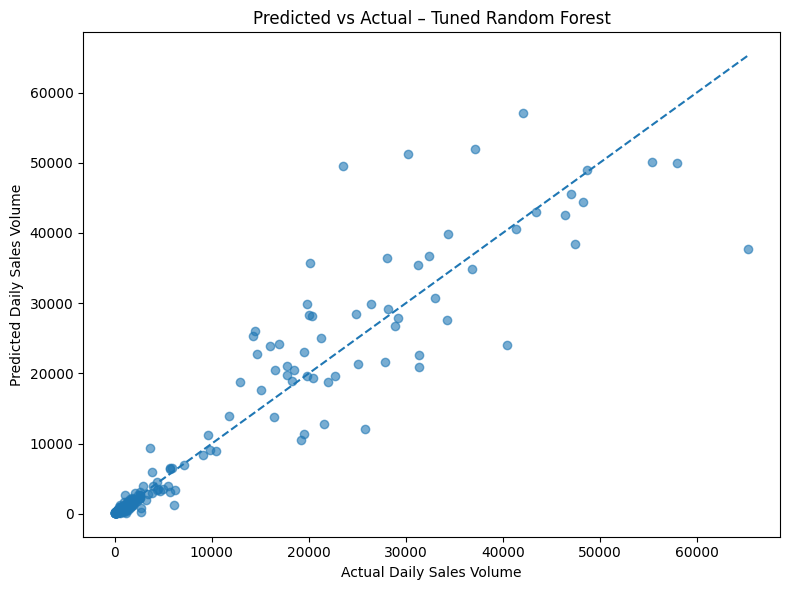

In [68]:
# Predictions from the tuned Random Forest
rf_final_pred_log = rf_tuned_model.predict(X_test_scaled)

# Convert predictions back from log scale
rf_final_pred = np.expm1(rf_final_pred_log)

# Ensure predictions are non-negative
rf_final_pred = np.maximum(rf_final_pred, 0)

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_original,
    rf_final_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test_original.min(), rf_final_pred.min())
max_value = max(y_test_original.max(), rf_final_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Daily Sales Volume")
plt.ylabel("Predicted Daily Sales Volume")
plt.title("Predicted vs Actual – Tuned Random Forest")

plt.tight_layout()
plt.show()

## Residual Plot – Tuned Random Forest

Residuals represent the difference between the actual and predicted values.

A residual is calculated as:

Residual = Actual Value − Predicted Value

The residual plot helps evaluate whether the model's errors are randomly distributed.

Ideally, the residuals should be scattered randomly around the horizontal zero line, without a clear pattern. A random distribution indicates that the model has captured the main relationship in the data.

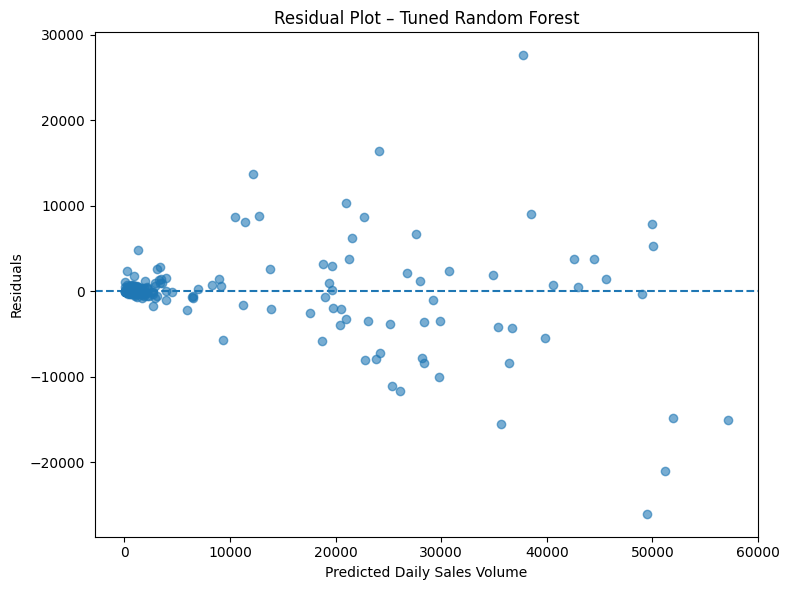

In [69]:
# Calculate residuals
rf_residuals = y_test_original - rf_final_pred

# Residual plot
plt.figure(figsize=(8, 6))

plt.scatter(
    rf_final_pred,
    rf_residuals,
    alpha=0.6
)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Daily Sales Volume")
plt.ylabel("Residuals")
plt.title("Residual Plot – Tuned Random Forest")

plt.tight_layout()
plt.show()

## Feature Importance – Tuned Random Forest

Feature importance shows the relative contribution of each input feature to the predictions made by the Random Forest.

The Random Forest calculates an importance value for each feature based on how much that feature contributes to reducing prediction error across the decision trees.

Higher feature importance indicates that the feature was more influential in the model's predictions.

The feature importances are visualized using a horizontal bar chart, with the most important features shown at the top.

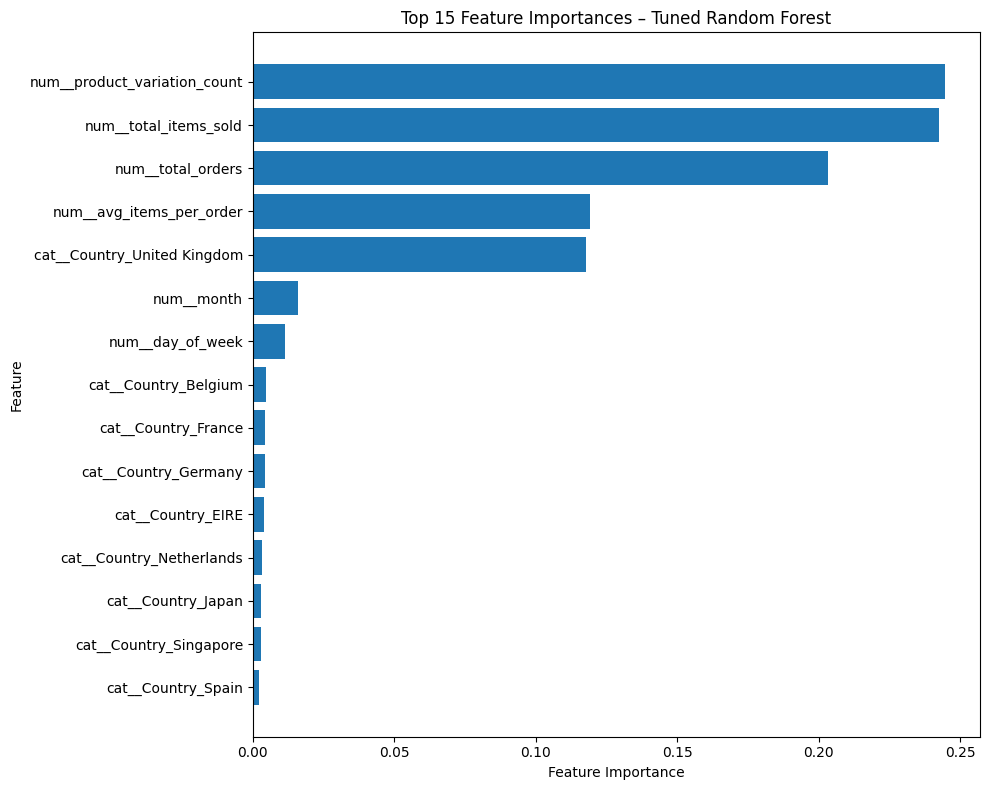

In [70]:
# Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from the tuned Random Forest
rf_importances = rf_tuned_model.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot feature importance
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_df["Feature"].head(15)[::-1],
    feature_importance_df["Importance"].head(15)[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances – Tuned Random Forest")

plt.tight_layout()
plt.show()

In [71]:
# Final evaluation of tuned SVR
svr_final_pred_log = svr_tuned_model.predict(X_test_scaled)
svr_final_pred = np.expm1(svr_final_pred_log)
svr_final_pred = np.maximum(svr_final_pred, 0)

svr_final_r2 = r2_score(y_test_original, svr_final_pred)
svr_final_rmse = np.sqrt(mean_squared_error(y_test_original, svr_final_pred))
svr_final_mae = mean_absolute_error(y_test_original, svr_final_pred)

# Final evaluation of tuned Random Forest
rf_final_pred_log = rf_tuned_model.predict(X_test_scaled)
rf_final_pred = np.expm1(rf_final_pred_log)
rf_final_pred = np.maximum(rf_final_pred, 0)

rf_final_r2 = r2_score(y_test_original, rf_final_pred)
rf_final_rmse = np.sqrt(mean_squared_error(y_test_original, rf_final_pred))
rf_final_mae = mean_absolute_error(y_test_original, rf_final_pred)

print("Tuned SVR")
print("R²:", round(svr_final_r2, 4))
print("RMSE:", round(svr_final_rmse, 2))
print("MAE:", round(svr_final_mae, 2))

print("\nTuned Random Forest")
print("R²:", round(rf_final_r2, 4))
print("RMSE:", round(rf_final_rmse, 2))
print("MAE:", round(rf_final_mae, 2))

print("\nImprovement in R²")
print("SVR:", round(svr_final_r2 - svr_r2, 4))
print("Random Forest:", round(rf_final_r2 - random_forest_r2, 4))

Tuned SVR
R²: 0.8427
RMSE: 4758.58
MAE: 1813.96

Tuned Random Forest
R²: 0.8922
RMSE: 3939.84
MAE: 1521.9

Improvement in R²
SVR: -0.0537
Random Forest: 0.0136


### Tuning Results

Hyperparameter tuning produced different effects on the held-out test set.
The tuned Random Forest improved its R² from 0.8786 to 0.8922,
an improvement of 0.0136.

The tuned SVR changed from 0.8964 to 0.8427,
a decrease of 0.0537 in held-out test R².

The tuned Random Forest is therefore used for the final visual analysis.